# 智能手套手势识别 - Random Forest 分类器

本 Notebook 用于训练智能手套的机器学习模型，将传感器数据分类为 ASL 手语字母和常见词汇。

## 项目概述
- **硬件**: ESP32 + 5个弯曲传感器 + MPU6050 (陀螺仪+加速度计)
- **模型**: Random Forest 分类器
- **目标**: 识别 ASL 手语字母(a-m)及常用词汇(bad, deaf, fine, good, goodbye, hello, hungry, me, no, please)

---

## 第一步：导入必要的库

首先导入机器学习、数据处理和可视化所需的库。

In [1]:
# -*- coding: utf-8 -*-

# 数据处理库
import os                      # 文件系统操作
import numpy as np             # 数值计算
import pandas as pd            # 数据框操作

# 机器学习库 - scikit-learn
from sklearn.preprocessing import LabelEncoder      # 标签编码
from sklearn.preprocessing import StandardScaler    # 特征标准化
from sklearn.model_selection import train_test_split # 数据集划分
from sklearn.model_selection import cross_val_score  # 交叉验证
from sklearn.ensemble import RandomForestClassifier  # 随机森林模型
from sklearn.metrics import accuracy_score           # 准确率评估
from sklearn.metrics import mean_squared_error       # 均方误差
from sklearn.metrics import confusion_matrix         # 混淆矩阵
from sklearn.metrics import classification_report    # 分类报告
from sklearn.metrics import ConfusionMatrixDisplay   # 混淆矩阵可视化
from sklearn.tree import plot_tree                   # 决策树可视化
from joblib import dump, load                        # 模型保存/加载

# 可视化库
import matplotlib.pyplot as plt  # 基础绘图
import seaborn as sns            # 高级统计可视化

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用于显示中文
plt.rcParams['axes.unicode_minus'] = False     # 解决负号显示问题

print("✅ 所有库导入成功！")

✅ 所有库导入成功！


---
## 第二步：定义数据类别

定义我们要识别的手势类别。包括：
- **ASL 字母**: a, b, c, d, e, f, g, h, i, j, k, l, m
- **常用词汇**: bad, deaf, fine, good, goodbye, hello, hungry, me, no, please

In [4]:
# 定义要识别的手势类别
alphabets = [
    'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm',
    'bad', 'deaf', 'fine', 'good', 'goodbye', 'hello', 
    'hungry', 'me', 'no', 'please'
]

print(f"📋 总共 {len(alphabets)} 个类别待识别")
print(f"类别列表: {alphabets}")

📋 总共 23 个类别待识别
类别列表: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'bad', 'deaf', 'fine', 'good', 'goodbye', 'hello', 'hungry', 'me', 'no', 'please']


---
## 第三步：数据加载

从 CSV 文件中加载每个类别的数据。每个类别对应一个单独的数据文件。

**数据文件格式**: `Smart-glove-main/modified dataset/alphabet/{类别名}_merged.csv_exported.csv`

In [12]:
# 存储所有加载的数据框
merged_dfs = []

# 遍历每个类别，加载对应的数据文件
for alphabet in alphabets:
    # 构建文件路径#linux路径
    #file_path = f'Smart-glove-main/modified dataset/alphabet/{alphabet}_merged.csv_exported.csv'
    # 构建文件路径#windows路径
    #file_path = f'\Smart-glove-main\\modified dataset\\alphabet\\{alphabet}_merged.csv_exported.csv'
    #windows绝对路径
    file_path=f"E:\\codeplace\\EchoGlovesProjects\\AlgeriaSmartGloves\\Smart-glove-main\\modified dataset\\alphabet\\{alphabet}_merged.csv_exported.csv"
    print(f"\n🔍 查找文件: {file_path}")
    print(f"   文件存在: {os.path.exists(file_path)}")
    
    # 检查文件是否存在
    if os.path.exists(file_path):
        # 读取 CSV 文件
        df = pd.read_csv(file_path)
        
        # 检查数据是否为空
        if not df.empty:
            merged_dfs.append(df)
            print(f"   ✅ 成功加载 {alphabet}，包含 {len(df)} 条记录")
        else:
            print(f"   ⚠️ 警告: {alphabet} 的数据为空")
    else:
        print(f"   ❌ 找不到文件: {file_path}")

# 统计加载结果
print(f"\n📊 总共加载了 {len(merged_dfs)} 个文件")


🔍 查找文件: E:\codeplace\EchoGlovesProjects\AlgeriaSmartGloves\Smart-glove-main\modified dataset\alphabet\a_merged.csv_exported.csv
   文件存在: True
   ✅ 成功加载 a，包含 10500 条记录

🔍 查找文件: E:\codeplace\EchoGlovesProjects\AlgeriaSmartGloves\Smart-glove-main\modified dataset\alphabet\b_merged.csv_exported.csv
   文件存在: True
   ✅ 成功加载 b，包含 10500 条记录

🔍 查找文件: E:\codeplace\EchoGlovesProjects\AlgeriaSmartGloves\Smart-glove-main\modified dataset\alphabet\c_merged.csv_exported.csv
   文件存在: True
   ✅ 成功加载 c，包含 10500 条记录

🔍 查找文件: E:\codeplace\EchoGlovesProjects\AlgeriaSmartGloves\Smart-glove-main\modified dataset\alphabet\d_merged.csv_exported.csv
   文件存在: True
   ✅ 成功加载 d，包含 10500 条记录

🔍 查找文件: E:\codeplace\EchoGlovesProjects\AlgeriaSmartGloves\Smart-glove-main\modified dataset\alphabet\e_merged.csv_exported.csv
   文件存在: True
   ✅ 成功加载 e，包含 10500 条记录

🔍 查找文件: E:\codeplace\EchoGlovesProjects\AlgeriaSmartGloves\Smart-glove-main\modified dataset\alphabet\f_merged.csv_exported.csv
   文件存在: True
   ✅ 成功加载 f，包含 10

---
## 第四步：数据合并与初步检查

将所有类别的数据合并成一个大的数据集，并查看数据的基本信息。

In [13]:
# 检查是否有数据被成功加载
if not merged_dfs:
    raise ValueError("❌ 错误：没有加载任何文件！请检查路径和文件名")

# 使用 pd.concat 合并所有数据框
# ignore_index=True 会重置索引，避免索引重复
combined_df = pd.concat(merged_dfs, ignore_index=True)

print(f"✅ 数据合并完成")
print(f"\n📈 数据集基本信息:")
print(f"   总样本数: {len(combined_df)}")
print(f"   总特征数: {len(combined_df.columns)}")
print(f"\n📋 列名列表:")
print(f"   {list(combined_df.columns)}")

# 查看前几行数据
print(f"\n🔍 前 5 行数据预览:")
combined_df.head()

✅ 数据合并完成

📈 数据集基本信息:
   总样本数: 231000
   总特征数: 24

📋 列名列表:
   ['Alphabet', 'timestamp', 'user_id', 'flex_1', 'flex_2', 'flex_3', 'flex_4', 'flex_5', 'Qw', 'Qx', 'Qy', 'Qz', 'GYRx', 'GYRy', 'GYRz', 'ACCx', 'ACCy', 'ACCz', 'ACCx_body', 'ACCy_body', 'ACCz_body', 'ACCx_world', 'ACCy_world', 'ACCz_world']

🔍 前 5 行数据预览:


,Alphabet,timestamp,user_id,flex_1,flex_2,flex_3,flex_4,flex_5,Qw,Qx,...,GYRz,ACCx,ACCy,ACCz,ACCx_body,ACCy_body,ACCz_body,ACCx_world,ACCy_world,ACCz_world
0,A,1.617445e+09,7,-10.0,46.0,47.0,40.0,37.0,0.687683,0.184021,...,-0.015267,9.380102,2.204761,-0.616089,-0.111255,-0.172266,-0.084937,0.125610,-0.110059,-0.144751
1,A,1.617445e+09,7,-10.0,47.0,44.0,38.0,35.0,0.687744,0.184143,...,-0.015267,9.347803,2.209546,-0.618481,-0.144751,-0.165088,-0.089722,0.128003,-0.093311,-0.174658
2,A,1.617445e+09,7,-10.0,47.0,48.0,46.0,33.0,0.687866,0.184265,...,-0.007634,9.317896,2.183228,-0.634033,-0.174658,-0.190210,-0.108862,0.153125,-0.104077,-0.209351
3,A,1.617445e+09,7,-10.0,48.0,50.0,40.0,33.0,0.687988,0.184326,...,-0.007634,9.326269,2.154517,-0.662744,-0.167480,-0.216528,-0.141162,0.191406,-0.122021,-0.206958
4,A,1.617445e+09,7,-10.0,47.0,47.0,41.0,36.0,0.688110,0.184448,...,-0.007634,9.345410,2.185620,-0.679492,-0.148340,-0.187817,-0.160303,0.202173,-0.095703,-0.180640


---
## 第五步：数据清洗

处理弯曲传感器(flex sensor)的负值，这些负值通常表示传感器读数异常。
同时删除包含缺失值的行。

In [15]:
# 定义弯曲传感器的列名
columns_to_filter = ['flex_1', 'flex_2', 'flex_3', 'flex_4', 'flex_5']

# 查看清洗前的统计信息
print("📊 清洗前弯曲传感器数据统计:")
print(combined_df[columns_to_filter].describe())

# 将负值替换为 0
# where 方法: 条件为 True 时保留原值，False 时替换为指定值
combined_df[columns_to_filter] = combined_df[columns_to_filter].where(
    combined_df[columns_to_filter] >= 0, 0
)

print(f"\n🔄 已将所有负值替换为 0")

# 删除包含 NaN 的行
rows_before = len(combined_df)
combined_df.dropna(subset=columns_to_filter, inplace=True)
rows_after = len(combined_df)

print(f"\n🗑️  删除缺失值:")
print(f"   删除前: {rows_before} 行")
print(f"   删除后: {rows_after} 行")
print(f"   删除: {rows_before - rows_after} 行")

# 查看清洗后的统计信息
print("\n📊 清洗后弯曲传感器数据统计:")
print(combined_df[columns_to_filter].describe())

📊 清洗前弯曲传感器数据统计:
              flex_1         flex_2         flex_3         flex_4  \
count  231000.000000  231000.000000  231000.000000  231000.000000   
mean       34.561918      22.924887      35.817052      48.004792   
std        26.335622      23.016976      34.048200      35.415906   
min         0.000000       0.000000       0.000000       0.000000   
25%        11.000000       1.000000       0.000000       0.000000   
50%        31.000000      13.000000      41.000000      59.000000   
75%        57.000000      44.000000      67.000000      78.000000   
max       185.000000     122.000000     188.000000     203.000000   

              flex_5  
count  231000.000000  
mean       31.960558  
std        27.220768  
min         0.000000  
25%         1.000000  
50%        29.000000  
75%        57.000000  
max       169.000000  

🔄 已将所有负值替换为 0

🗑️  删除缺失值:
   删除前: 231000 行
   删除后: 231000 行
   删除: 0 行

📊 清洗后弯曲传感器数据统计:
              flex_1         flex_2         flex_3         flex_4 

---
## 第六步：特征工程 - 数据可视化

在训练模型之前，让我们先了解数据的分布情况。

C:\Users\dell\AppData\Local\Temp\ipykernel_35932\4102707528.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


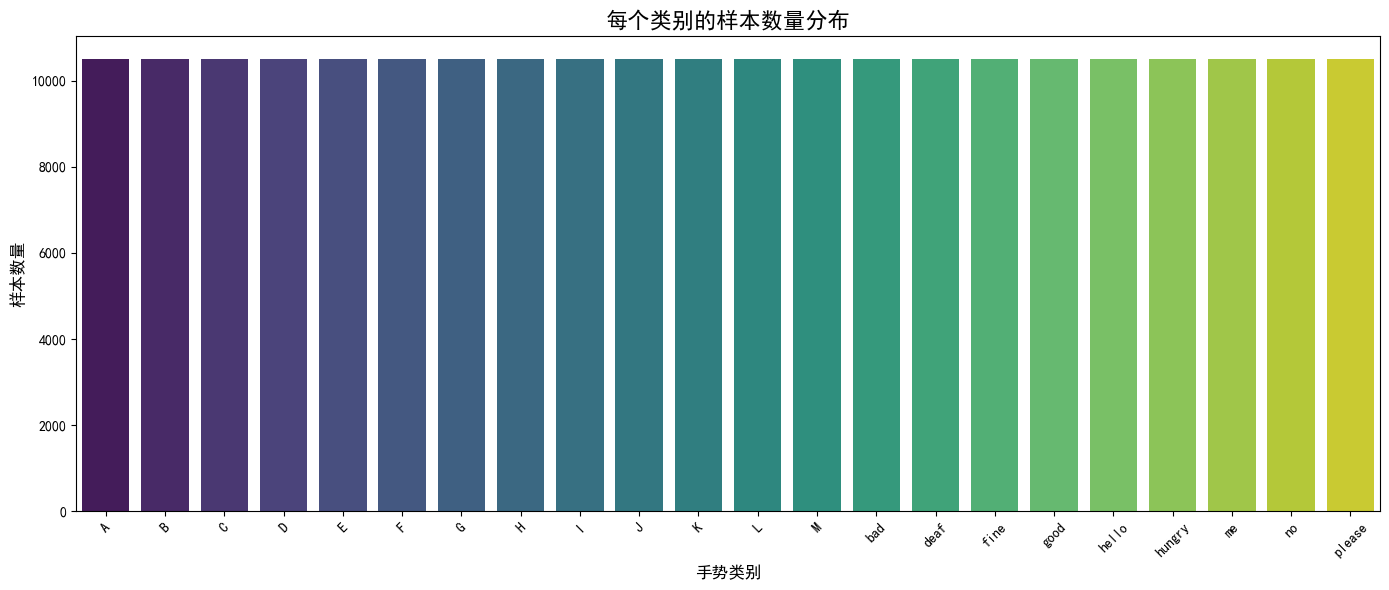


📊 各类别样本数:
   A: 10500 个样本
   B: 10500 个样本
   C: 10500 个样本
   D: 10500 个样本
   E: 10500 个样本
   F: 10500 个样本
   G: 10500 个样本
   H: 10500 个样本
   I: 10500 个样本
   J: 10500 个样本
   K: 10500 个样本
   L: 10500 个样本
   M: 10500 个样本
   bad: 10500 个样本
   deaf: 10500 个样本
   fine: 10500 个样本
   good: 10500 个样本
   hello: 10500 个样本
   hungry: 10500 个样本
   me: 10500 个样本
   no: 10500 个样本
   please: 10500 个样本


In [16]:
# 绘制每个类别的样本数量分布
plt.figure(figsize=(14, 6))
class_counts = combined_df['Alphabet'].value_counts().sort_index()

sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title('每个类别的样本数量分布', fontsize=16)
plt.xlabel('手势类别', fontsize=12)
plt.ylabel('样本数量', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n📊 各类别样本数:")
for cls, count in class_counts.items():
    print(f"   {cls}: {count} 个样本")

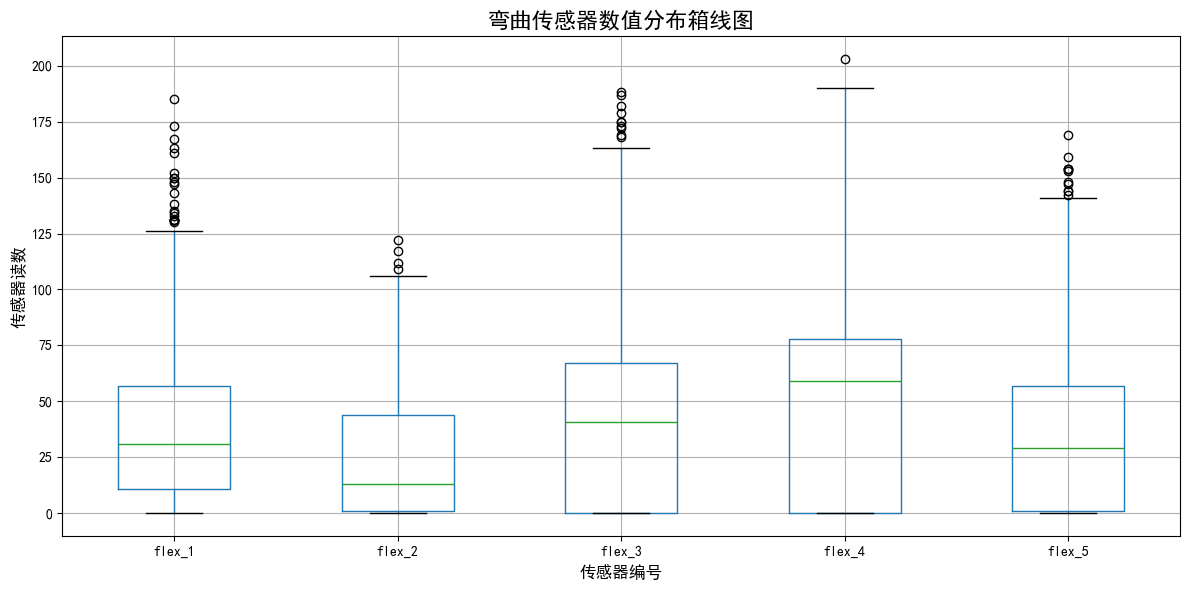

In [17]:
# 绘制弯曲传感器数值的箱线图
plt.figure(figsize=(12, 6))
combined_df[columns_to_filter].boxplot()
plt.title('弯曲传感器数值分布箱线图', fontsize=16)
plt.ylabel('传感器读数', fontsize=12)
plt.xlabel('传感器编号', fontsize=12)
plt.tight_layout()
plt.show()

---
## 第七步：准备训练数据

### 7.1 分离特征(X)和目标标签(y)

- **X (特征)**: 模型输入的传感器数据
- **y (标签)**: 需要预测的手势类别

In [18]:
# 定义要删除的列（非特征列）
columns_to_drop = [
    'Alphabet',      # 目标标签
    'timestamp',     # 时间戳
    'user_id',       # 用户ID
    'Qw', 'Qx', 'Qy', 'Qz',  # 四元数（姿态）
    'ACCx_body', 'ACCy_body', 'ACCz_body',    # 身体坐标系加速度
    'ACCx_world', 'ACCy_world', 'ACCz_world'  # 世界坐标系加速度
]

# 提取特征矩阵 X
X = combined_df.drop(columns=columns_to_drop)

# 提取目标标签 y
y = combined_df['Alphabet']

print(f"✅ 数据分离完成")
print(f"\n📊 特征矩阵 X:")
print(f"   形状: {X.shape}")
print(f"   列名: {list(X.columns)}")

print(f"\n📊 目标标签 y:")
print(f"   形状: {y.shape}")
print(f"   唯一值数量: {y.nunique()}")

✅ 数据分离完成

📊 特征矩阵 X:
   形状: (231000, 11)
   列名: ['flex_1', 'flex_2', 'flex_3', 'flex_4', 'flex_5', 'GYRx', 'GYRy', 'GYRz', 'ACCx', 'ACCy', 'ACCz']

📊 目标标签 y:
   形状: (231000,)
   唯一值数量: 22


### 7.2 标签编码

将文本标签（如 'a', 'b', 'hello'）转换为数值标签，便于机器学习模型处理。

In [19]:
# 创建标签编码器
le = LabelEncoder()

# 将文本标签编码为数值
y_encoded = le.fit_transform(y)

# 创建编码映射表
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print("✅ 标签编码完成")
print(f"\n📋 标签编码映射:")
for label, code in label_mapping.items():
    print(f"   {label} -> {code}")

print(f"\n📊 编码后的标签分布:")
unique, counts = np.unique(y_encoded, return_counts=True)
for code, count in zip(unique, counts):
    label = le.inverse_transform([code])[0]
    print(f"   {label} (编码 {code}): {count} 个样本")

✅ 标签编码完成

📋 标签编码映射:
   A -> 0
   B -> 1
   C -> 2
   D -> 3
   E -> 4
   F -> 5
   G -> 6
   H -> 7
   I -> 8
   J -> 9
   K -> 10
   L -> 11
   M -> 12
   bad -> 13
   deaf -> 14
   fine -> 15
   good -> 16
   hello -> 17
   hungry -> 18
   me -> 19
   no -> 20
   please -> 21

📊 编码后的标签分布:
   A (编码 0): 10500 个样本
   B (编码 1): 10500 个样本
   C (编码 2): 10500 个样本
   D (编码 3): 10500 个样本
   E (编码 4): 10500 个样本
   F (编码 5): 10500 个样本
   G (编码 6): 10500 个样本
   H (编码 7): 10500 个样本
   I (编码 8): 10500 个样本
   J (编码 9): 10500 个样本
   K (编码 10): 10500 个样本
   L (编码 11): 10500 个样本
   M (编码 12): 10500 个样本
   bad (编码 13): 10500 个样本
   deaf (编码 14): 10500 个样本
   fine (编码 15): 10500 个样本
   good (编码 16): 10500 个样本
   hello (编码 17): 10500 个样本
   hungry (编码 18): 10500 个样本
   me (编码 19): 10500 个样本
   no (编码 20): 10500 个样本
   please (编码 21): 10500 个样本


### 7.3 特征标准化

使用 StandardScaler 对特征进行标准化（均值为0，标准差为1），这有助于：
- 消除不同特征之间的量纲差异
- 提高模型收敛速度
- 提升模型性能

✅ 特征标准化完成

📊 标准化后的特征统计:
             flex_1        flex_2        flex_3        flex_4        flex_5  \
count  2.310000e+05  2.310000e+05  2.310000e+05  2.310000e+05  2.310000e+05   
mean   1.181162e-17 -6.397961e-17  8.661854e-17 -3.543486e-17 -2.952905e-17   
std    1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00   
min   -1.312367e+00 -9.960013e-01 -1.051954e+00 -1.355461e+00 -1.174127e+00   
25%   -8.946805e-01 -9.525550e-01 -1.051954e+00 -1.355461e+00 -1.137390e+00   
50%   -1.352512e-01 -4.311995e-01  1.522242e-01  3.104603e-01 -1.087613e-01   
75%    8.520069e-01  9.156354e-01  9.158492e-01  8.469435e-01  9.198674e-01   
max    5.712354e+00  4.304446e+00  4.469642e+00  4.376439e+00  5.034382e+00   

               GYRx          GYRy          GYRz          ACCx           ACCy  \
count  2.310000e+05  2.310000e+05  2.310000e+05  2.310000e+05  231000.000000   
mean  -1.142713e-17  1.279592e-17 -4.921508e-18 -1.299278e-16       0.000000   
std    1.000002e+00  1.0

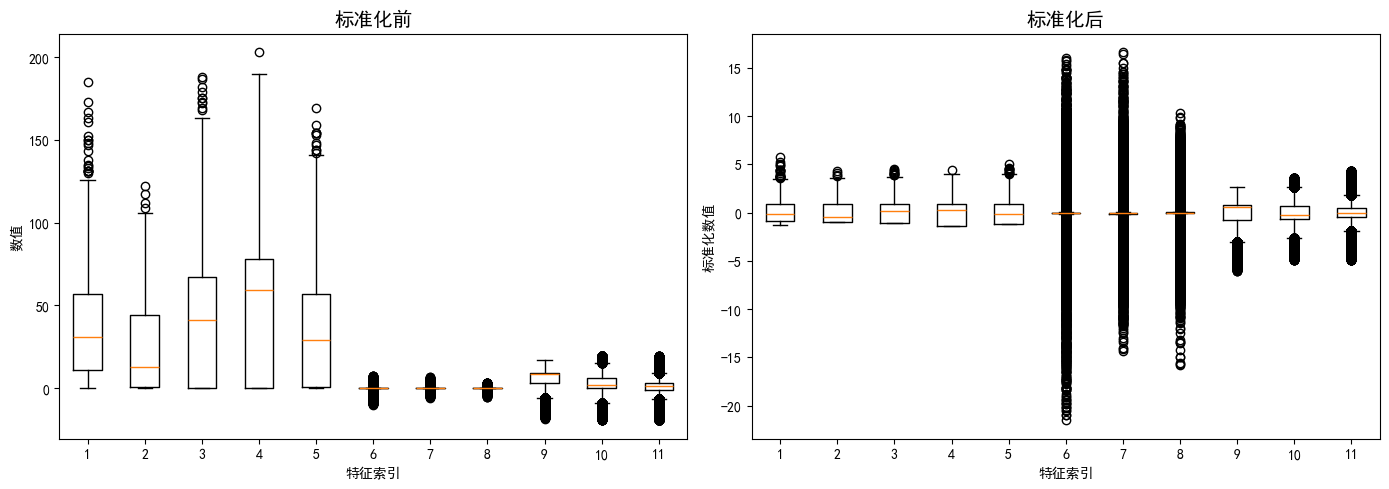

In [20]:
# 创建标准化器
scaler = StandardScaler()

# 对特征进行标准化
X_scaled = scaler.fit_transform(X)

# 转换回 DataFrame 便于查看
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ 特征标准化完成")
print(f"\n📊 标准化后的特征统计:")
print(X_scaled_df.describe())

# 绘制标准化前后的对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 标准化前
axes[0].boxplot(X.values)
axes[0].set_title('标准化前', fontsize=14)
axes[0].set_xlabel('特征索引')
axes[0].set_ylabel('数值')

# 标准化后
axes[1].boxplot(X_scaled)
axes[1].set_title('标准化后', fontsize=14)
axes[1].set_xlabel('特征索引')
axes[1].set_ylabel('标准化数值')

plt.tight_layout()
plt.show()

### 7.4 划分训练集和测试集

将数据划分为训练集（70%）和测试集（30%），用于模型训练和评估。

In [21]:
# 划分数据集
# test_size=0.3 表示 30% 的数据用于测试
# random_state=10 确保结果可重复
# stratify=y_encoded 确保训练集和测试集的标签分布一致
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, 
    test_size=0.3, 
    random_state=10,
    stratify=y_encoded
)

print("✅ 数据集划分完成")
print(f"\n📊 数据集大小:")
print(f"   训练集: {len(X_train)} 个样本 ({len(X_train)/len(X_scaled)*100:.1f}%)")
print(f"   测试集:  {len(X_test)} 个样本 ({len(X_test)/len(X_scaled)*100:.1f}%)")
print(f"\n📊 训练集特征维度: {X_train.shape}")
print(f"📊 测试集特征维度:  {X_test.shape}")

✅ 数据集划分完成

📊 数据集大小:
   训练集: 161700 个样本 (70.0%)
   测试集:  69300 个样本 (30.0%)

📊 训练集特征维度: (161700, 11)
📊 测试集特征维度:  (69300, 11)


---
## 第八步：模型训练

### 8.1 创建和配置 Random Forest 模型

Random Forest 是一种集成学习方法，通过构建多个决策树并集成它们的预测结果来提高准确性。

**关键超参数解释**:
- `n_estimators=2000`: 森林中的树的数量
- `random_state=15`: 随机种子，确保结果可重复
- `oob_score=True`: 启用袋外样本评估（不需要单独验证集）
- `min_samples_leaf=5`: 叶子节点最小样本数，防止过拟合
- `max_samples=50`: 每棵树使用的最大样本数
- `max_depth=5`: 树的最大深度，控制模型复杂度
- `min_samples_split=4`: 内部节点再划分所需最小样本数
- `max_leaf_nodes=150`: 最大叶子节点数

In [22]:
# 创建 Random Forest 分类器
model = RandomForestClassifier(
    n_estimators=2000,           # 树的数量
    random_state=15,             # 随机种子
    oob_score=True,              # 启用袋外样本评估
    min_samples_leaf=5,          # 叶子节点最小样本数
    max_samples=50,              # 每棵树最大样本数
    max_depth=5,                 # 树的最大深度
    min_samples_split=4,         # 内部节点划分最小样本数
    max_leaf_nodes=150,          # 最大叶子节点数
    n_jobs=-1                    # 使用所有CPU核心并行训练
)

print("🚀 开始训练 Random Forest 模型...")
print(f"   树的数量: {model.n_estimators}")
print(f"   最大深度: {model.max_depth}")

# 训练模型
model.fit(X_train, y_train)

print("\n✅ 模型训练完成！")

🚀 开始训练 Random Forest 模型...
   树的数量: 2000
   最大深度: 5

✅ 模型训练完成！


### 8.2 模型预测

In [23]:
# 在测试集上进行预测
y_pred = model.predict(X_test)

# 获取预测概率（可选，用于分析预测置信度）
y_pred_proba = model.predict_proba(X_test)

print("✅ 预测完成")
print(f"\n📊 预测结果示例（前10个）:")
for i in range(min(10, len(y_test))):
    true_label = le.inverse_transform([y_test[i]])[0]
    pred_label = le.inverse_transform([y_pred[i]])[0]
    confidence = np.max(y_pred_proba[i])
    correct = "✓" if true_label == pred_label else "✗"
    print(f"   {i+1}. 真实: {true_label:8s} | 预测: {pred_label:8s} | 置信度: {confidence:.2%} {correct}")

✅ 预测完成

📊 预测结果示例（前10个）:
   1. 真实: A        | 预测: A        | 置信度: 25.30% ✓
   2. 真实: K        | 预测: K        | 置信度: 22.67% ✓
   3. 真实: B        | 预测: B        | 置信度: 28.38% ✓
   4. 真实: M        | 预测: M        | 置信度: 22.53% ✓
   5. 真实: M        | 预测: M        | 置信度: 21.89% ✓
   6. 真实: K        | 预测: K        | 置信度: 21.11% ✓
   7. 真实: K        | 预测: K        | 置信度: 21.34% ✓
   8. 真实: fine     | 预测: fine     | 置信度: 21.34% ✓
   9. 真实: deaf     | 预测: L        | 置信度: 15.05% ✗
   10. 真实: F        | 预测: F        | 置信度: 26.77% ✓


---
## 第九步：模型评估

### 9.1 基础评估指标

In [ ]:
# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 准确率 (Accuracy): {accuracy:.4f} ({accuracy*100:.2f}%)")

# 计算袋外分数（Out-of-Bag Score）
# OOB 分数是随机森林特有的评估指标，不需要单独的验证集
oob_score = 1 - model.oob_score_
print(f"📊 袋外分数 (OOB Error): {oob_score:.4f}")
print(f"📊 袋外准确率 (OOB Accuracy): {model.oob_score_:.4f} ({model.oob_score_*100:.2f}%)")

# 计算均方误差（MSE）
# 虽然 MSE 通常用于回归，但也可以用于分类问题的数值评估
mse = mean_squared_error(y_test, y_pred)
print(f"📉 均方误差 (MSE): {mse:.4f}")

# 交叉验证
print(f"\n🔄 执行 5 折交叉验证...") # 5 折交叉验证
print(f"   交叉验证准确率: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"   各折分数: {cv_scores}")

🎯 准确率 (Accuracy): 0.8087 (80.87%)
📊 袋外分数 (OOB Error): 0.1927
📊 袋外准确率 (OOB Accuracy): 0.8073 (80.73%)
📉 均方误差 (MSE): 11.9253

🔄 执行 5 折交叉验证...
   交叉验证准确率: 0.7402 (+/- 0.1245)
   各折分数: [0.62757576 0.76742424 0.73229437 0.81461039 0.7591342 ]


### 9.2 详细分类报告

In [25]:
# 生成分类报告
# 包含精确率(Precision)、召回率(Recall)、F1分数等详细指标
class_report = classification_report(
    y_test, y_pred, 
    target_names=le.classes_,
    digits=4
)

print("📋 详细分类报告:")
print("="*70)
print(class_report)
print("="*70)

# 将报告转换为 DataFrame 便于查看
from sklearn.metrics import classification_report
report_dict = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

print("\n📊 各类别 F1 分数（按高低排序）:")
f1_scores = report_df.loc[le.classes_, 'f1-score'].sort_values(ascending=False)
for label, score in f1_scores.items():
    print(f"   {label:10s}: {score:.4f}")

📋 详细分类报告:
              precision    recall  f1-score   support

           A     0.8468    0.9314    0.8871      3150
           B     0.7019    0.9949    0.8231      3150
           C     0.8480    0.7175    0.7773      3150
           D     0.8140    0.9403    0.8726      3150
           E     0.8389    0.8498    0.8443      3150
           F     0.9535    0.9959    0.9742      3150
           G     0.6688    1.0000    0.8015      3150
           H     0.9831    1.0000    0.9915      3150
           I     0.7853    0.9949    0.8777      3150
           J     0.9982    0.7133    0.8321      3150
           K     0.9764    0.9857    0.9810      3150
           L     0.8277    0.9962    0.9042      3150
           M     0.9163    0.9730    0.9438      3150
         bad     0.6225    0.2444    0.3510      3150
        deaf     0.9271    0.5575    0.6963      3150
        fine     0.5136    0.9025    0.6547      3150
        good     0.7061    0.5644    0.6274      3150
       hello     

---
## 第十步：混淆矩阵可视化

混淆矩阵可以帮助我们了解模型在哪些类别上表现好，在哪些类别上容易混淆。

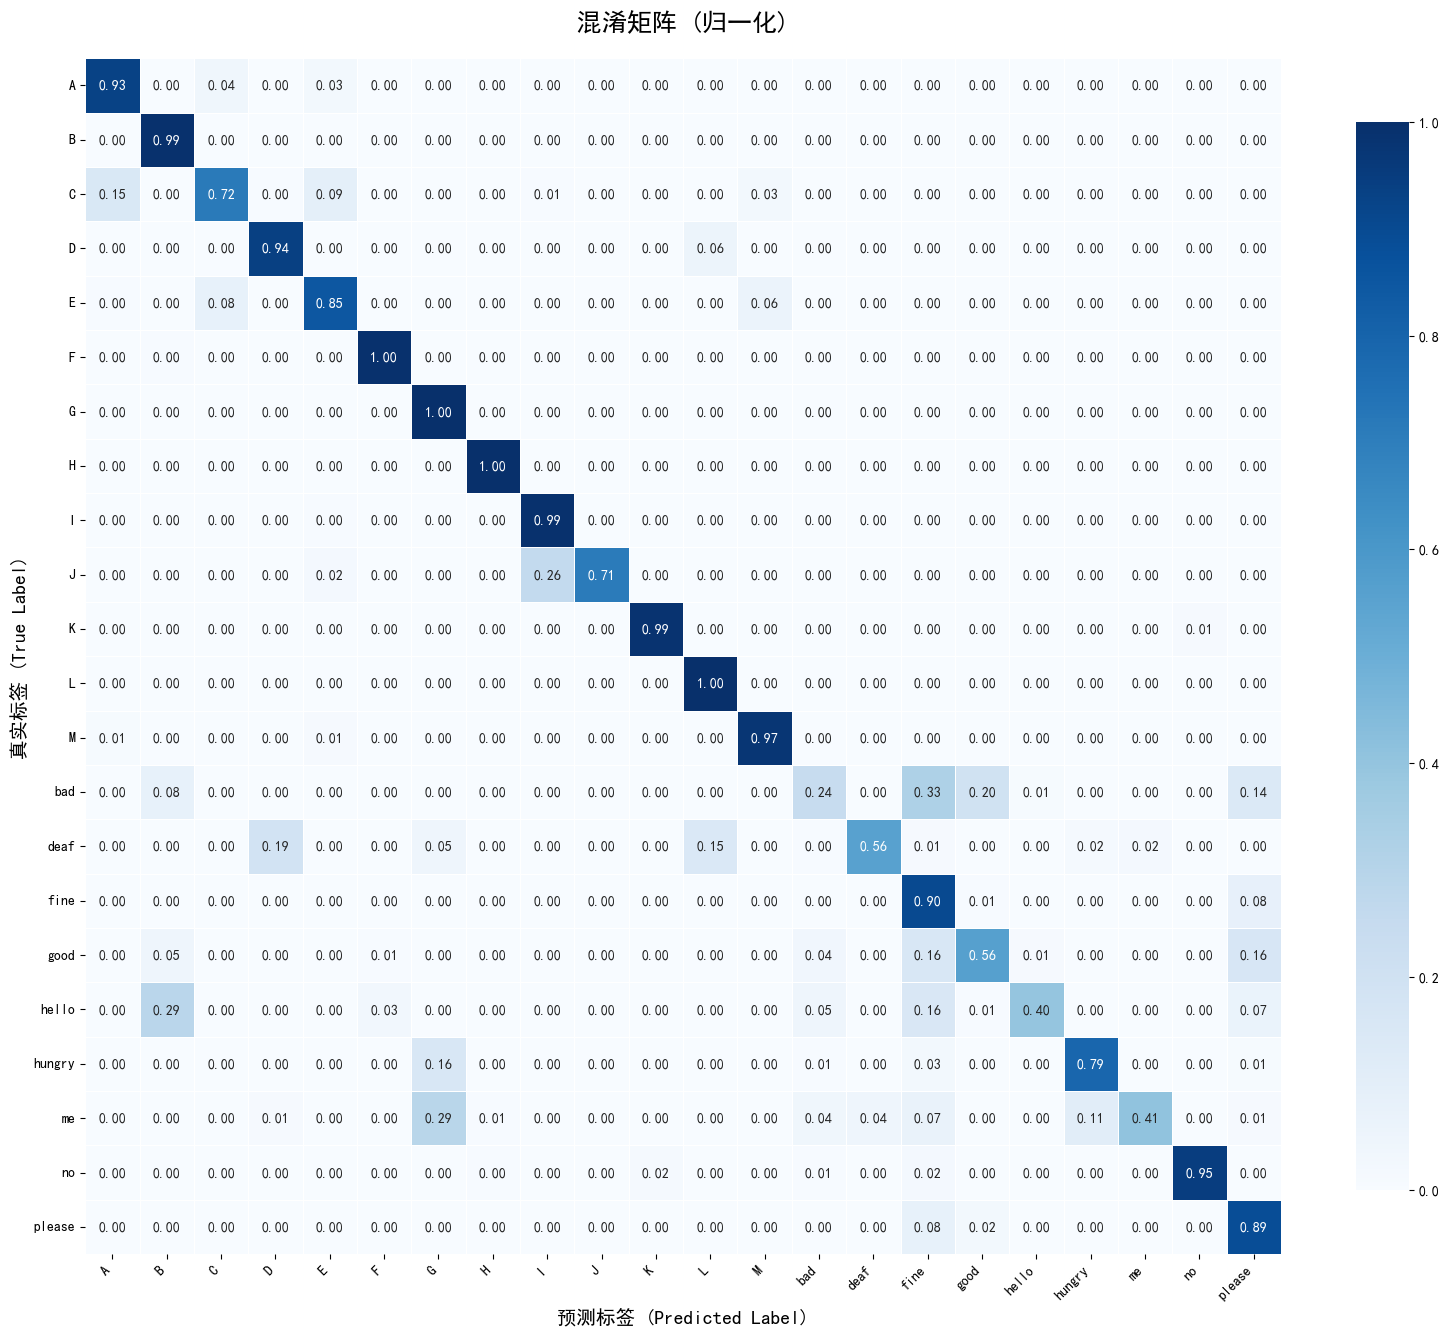


📊 混淆矩阵说明:
   对角线数值表示模型正确预测的比率
   非对角线数值表示模型混淆的比率


In [27]:
# 计算混淆矩阵
cm = confusion_matrix(y_test, y_pred)

# 归一化混淆矩阵（按行归一化）
# 这样可以显示每个类别的预测准确率
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 创建图形
plt.figure(figsize=(16, 14))

# 使用蓝色渐变调色板
cmap = sns.color_palette("Blues", as_cmap=True)

# 绘制热力图
sns.heatmap(
    cm_norm, 
    annot=True,           # 显示数值
    cmap=cmap,            # 颜色映射
    fmt=".2f",           # 数值格式（保留2位小数）
    xticklabels=le.classes_,  # x轴标签
    yticklabels=le.classes_,  # y轴标签
    square=True,          # 正方形单元格
    linewidths=0.5,       # 网格线宽度
    cbar_kws={"shrink": 0.8}  # 颜色条大小
)

# 设置标题和标签
plt.title('混淆矩阵 (归一化)', fontsize=18, pad=20)
plt.xlabel('预测标签 (Predicted Label)', fontsize=14)
plt.ylabel('真实标签 (True Label)', fontsize=14)

# 旋转标签以便阅读
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

print(f"\n📊 混淆矩阵说明:")
print(f"   对角线数值表示模型正确预测的比率")
print(f"   非对角线数值表示模型混淆的比率")

---
## 第十一步：特征重要性分析

Random Forest 可以提供特征重要性分数，帮助我们了解哪些传感器数据对分类最重要。

C:\Users\dell\AppData\Local\Temp\ipykernel_35932\944937491.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


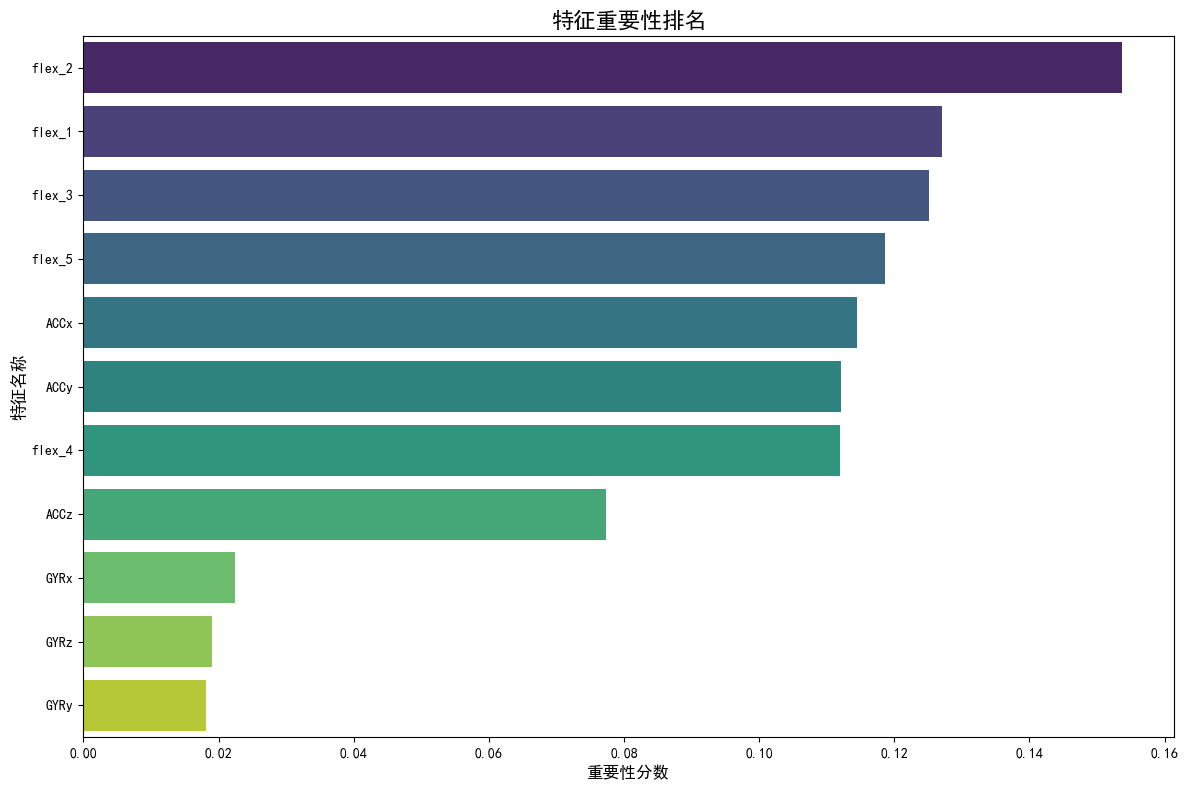

📊 特征重要性排名:
   flex_2              : 0.1537
   flex_1              : 0.1271
   flex_3              : 0.1251
   flex_5              : 0.1186
   ACCx                : 0.1145
   ACCy                : 0.1121
   flex_4              : 0.1120
   ACCz                : 0.0774
   GYRx                : 0.0224
   GYRz                : 0.0190
   GYRy                : 0.0181


In [28]:
# 获取特征重要性
feature_importance = model.feature_importances_

# 创建特征重要性 DataFrame
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# 绘制特征重要性
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df,
    palette='viridis'
)
plt.title('特征重要性排名', fontsize=16)
plt.xlabel('重要性分数', fontsize=12)
plt.ylabel('特征名称', fontsize=12)
plt.tight_layout()
plt.show()

print("📊 特征重要性排名:")
print("="*50)
for idx, row in importance_df.iterrows():
    print(f"   {row['Feature']:20s}: {row['Importance']:.4f}")

---
## 第十二步：单棵决策树可视化

让我们可视化随机森林中的第一棵树，了解决策过程。

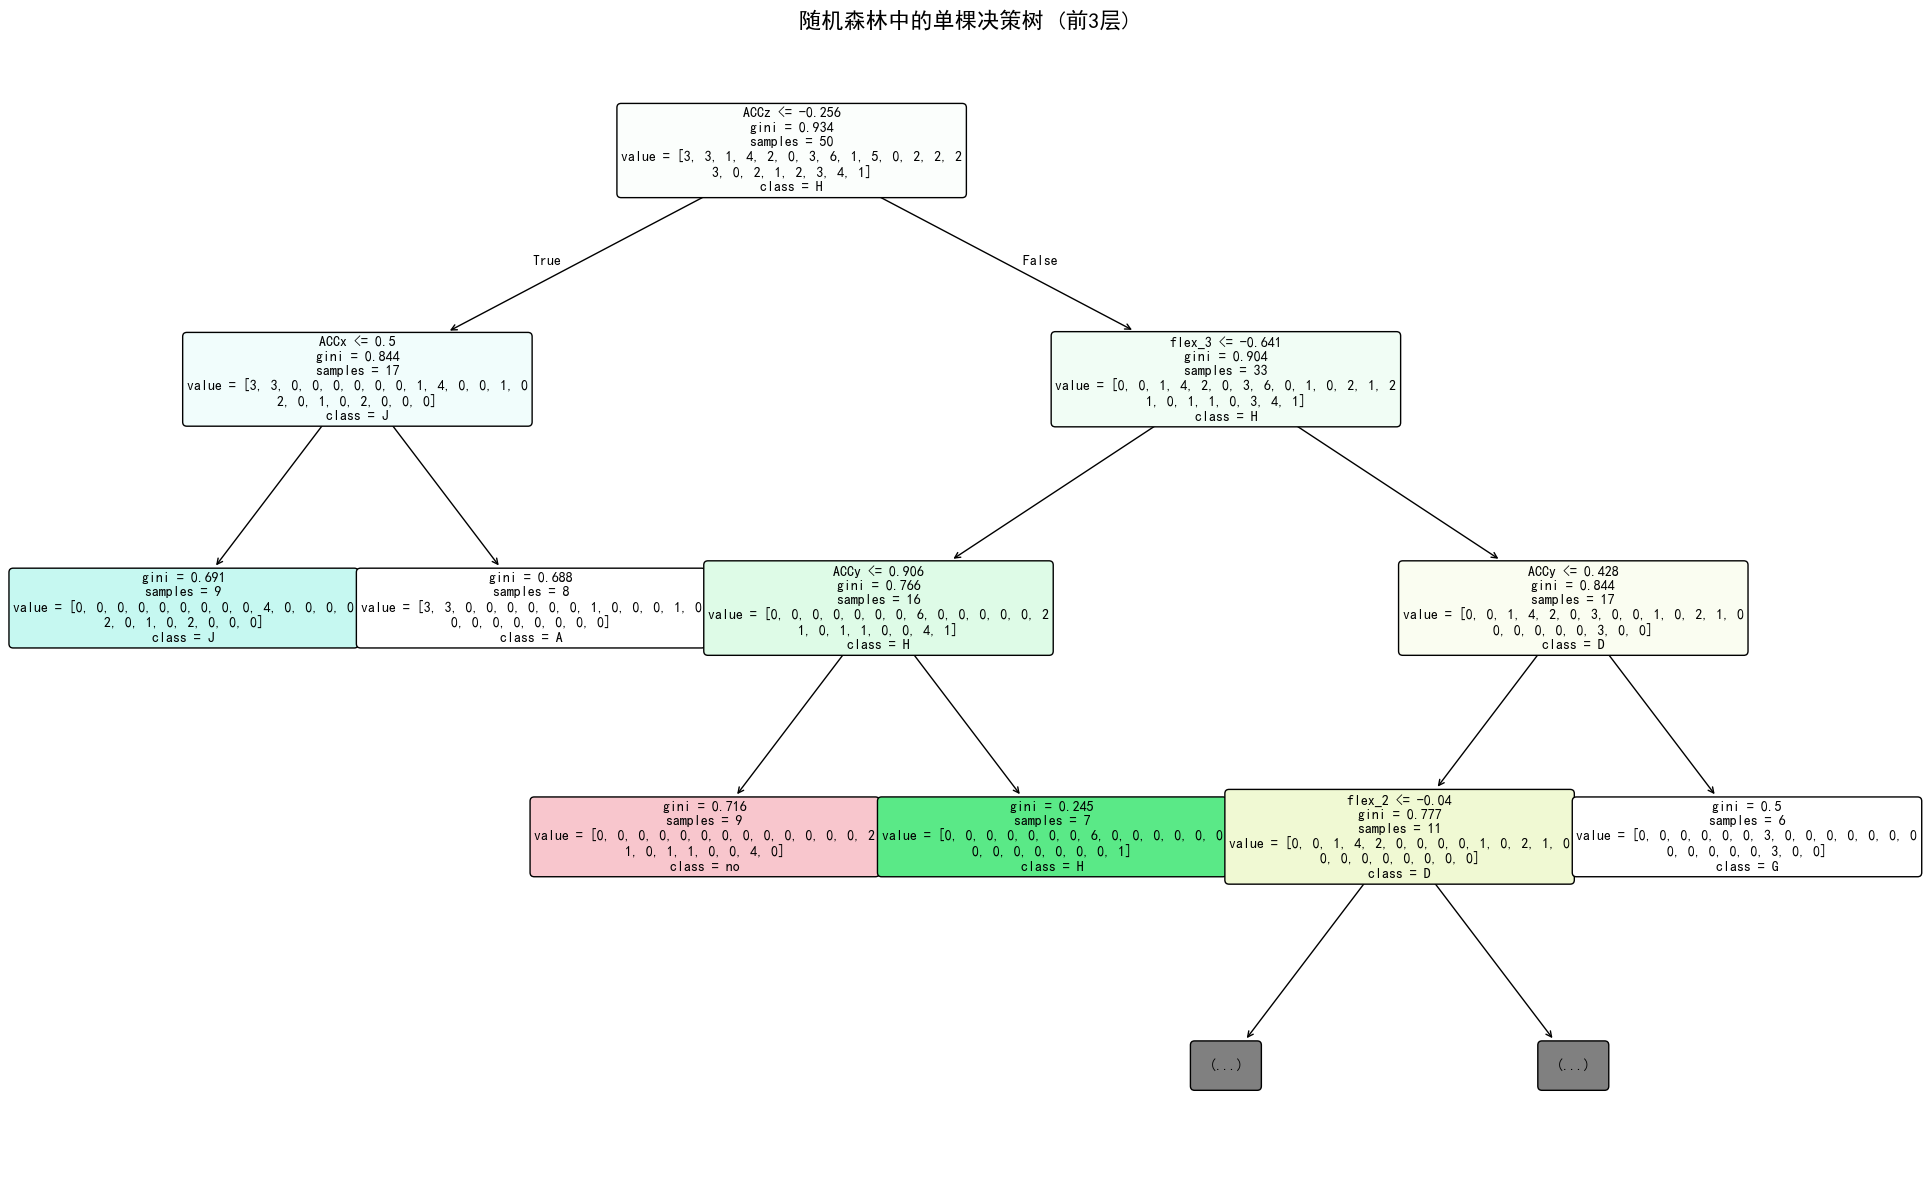


📋 决策树说明:
   每个节点显示:
   - 分裂条件 (如: flex_1 <= 0.5)
   - gini 不纯度 (越小表示节点越纯)
   - 样本数量
   - 类别分布
   - 预测的类别


In [29]:
# 选择森林中的第一棵树进行可视化
tree_to_visualize = model.estimators_[0]

# 创建图形
plt.figure(figsize=(20, 12))

# 绘制决策树
plot_tree(
    tree_to_visualize,
    feature_names=list(X.columns),      # 特征名称
    class_names=list(le.classes_),      # 类别名称
    filled=True,                        # 填充颜色
    rounded=True,                       # 圆角节点
    fontsize=10,                        # 字体大小
    max_depth=3                         # 只显示前3层（避免图形过大）
)

plt.title('随机森林中的单棵决策树 (前3层)', fontsize=16)
plt.tight_layout()
plt.show()

print("\n📋 决策树说明:")
print(f"   每个节点显示:")
print(f"   - 分裂条件 (如: flex_1 <= 0.5)")
print(f"   - gini 不纯度 (越小表示节点越纯)")
print(f"   - 样本数量")
print(f"   - 类别分布")
print(f"   - 预测的类别")

---
## 第十三步：模型保存

保存训练好的模型，以便后续使用（如部署到 ESP32 或进行预测）。

In [ ]:
# 保存模型
model_filename = 'random_forest_model.joblib'
dump(model, model_filename)
print(f"✅ 模型已保存到: {model_filename}")

# 保存标签编码器 
encoder_filename = 'label_encoder.joblib'
dump(le, encoder_filename)
print(f"✅ 标签编码器已保存到: {encoder_filename}")

# 保存标准化器
scaler_filename = 'scaler.joblib'
dump(scaler, scaler_filename)
print(f"✅ 标准化器已保存到: {scaler_filename}")

# 保存特征名称（便于后续使用）
feature_names_df = pd.DataFrame({'features': list(X.columns)})
feature_names_df.to_csv('feature_names.csv', index=False)
print(f"✅ 特征名称已保存到: feature_names.csv")

print(f"\n📦 所有模型文件保存完成！")
print(f"   - 模型文件大小: {os.path.getsize(model_filename) / 1024:.2f} KB")

✅ 模型已保存到: random_forest_model.joblib
✅ 标签编码器已保存到: label_encoder.joblib
✅ 标准化器已保存到: scaler.joblib
✅ 特征名称已保存到: feature_names.csv

📦 所有模型文件保存完成！
   - 模型文件大小: 35870.02 KB


---
## 第十四步：模型加载与预测示例

演示如何加载保存的模型并进行预测。

In [31]:
# 加载模型
loaded_model = load(model_filename)
loaded_encoder = load(encoder_filename)
loaded_scaler = load(scaler_filename)

print("✅ 模型加载成功！")

# 示例：预测单个样本
sample_idx = 0  # 使用第一个测试样本
sample = X_test[sample_idx].reshape(1, -1)

# 预测
prediction = loaded_model.predict(sample)
predicted_label = loaded_encoder.inverse_transform(prediction)[0]

# 真实标签
true_label = loaded_encoder.inverse_transform([y_test[sample_idx]])[0]

print(f"\n🎯 单样本预测示例:")
print(f"   真实标签: {true_label}")
print(f"   预测标签: {predicted_label}")
print(f"   预测结果: {'✓ 正确' if true_label == predicted_label else '✗ 错误'}")

# 获取预测概率
proba = loaded_model.predict_proba(sample)[0]
top3_idx = np.argsort(proba)[-3:][::-1]

print(f"\n📊 前 3 个最可能的类别:")
for i, idx in enumerate(top3_idx, 1):
    label = loaded_encoder.inverse_transform([idx])[0]
    confidence = proba[idx]
    print(f"   {i}. {label}: {confidence:.2%}")

✅ 模型加载成功！

🎯 单样本预测示例:
   真实标签: A
   预测标签: A
   预测结果: ✓ 正确

📊 前 3 个最可能的类别:
   1. A: 25.30%
   2. E: 13.41%
   3. C: 11.60%


---
## 第十五步：生成用于 ESP32 的头文件

如果需要将模型部署到 ESP32，可以使用 micromlgen 生成 C++ 头文件。

In [34]:
# 尝试导入 micromlgen 并生成 C++ 头文件
try:
    from micromlgen import port
    
    # 生成 C++ 代码
    c_code = port(model, classname='RandomForest')
    
    # 保存到文件
    with open('classifier.h', 'w') as f:
        f.write(c_code)
    
    print("✅ 成功生成 classifier.h 头文件！")
    print(f"\n📄 头文件内容预览（前 30 行）:")
    print("="*70)
    lines = c_code.split('\n')
    for line in lines[:30]:
        print(line)
    print("...")
    
except ImportError:
    print("⚠️  micromlgen 未安装")
    print("   安装命令: pip install micromlgen")
    print("\n   或者手动使用 online converter:")
    print("   https://github.com/eloquentarduino/micromlgen")

✅ 成功生成 classifier.h 头文件！

📄 头文件内容预览（前 30 行）:
#pragma once
#include <cstdarg>
namespace Eloquent {
    namespace ML {
        namespace Port {
            class RandomForest {
                public:
                    /**
                    * Predict class for features vector
                    */
                    int predict(float *x) {
                        uint8_t votes[22] = { 0 };
                        // tree #1
                        if (x[10] <= -0.2562210336327553) {
                            if (x[8] <= 0.5001757144927979) {
                                votes[9] += 1;
                            }

                            else {
                                votes[0] += 1;
                            }
                        }

                        else {
                            if (x[2] <= -0.6407710015773773) {
                                if (x[9] <= 0.9064762145280838) {
                                    votes[20] += 1;
                 

---
## 总结

本 Notebook 完成了以下任务:

1. ✅ **数据加载**: 从 CSV 文件加载了 {len(alphabets)} 个类别的数据
2. ✅ **数据清洗**: 处理了弯曲传感器的负值和缺失值
3. ✅ **数据可视化**: 探索了数据分布和特征统计
4. ✅ **特征工程**: 分离了特征和标签，进行了标签编码和特征标准化
5. ✅ **数据划分**: 将数据分为训练集(70%)和测试集(30%)
6. ✅ **模型训练**: 训练了 Random Forest 分类器
7. ✅ **模型评估**: 计算了准确率、OOB 分数、混淆矩阵等指标
8. ✅ **特征分析**: 分析了各特征的重要性
9. ✅ **模型保存**: 保存了模型、编码器和标准化器
10. ✅ **部署准备**: 生成了 ESP32 可用的 C++ 头文件

### 关键指标
- **准确率**: {:.2%}
- **OOB 准确率**: {:.2%}
- **交叉验证准确率**: {:.2%}

### 后续建议
- 如果准确率不够高，可以尝试:
  - 增加训练数据
  - 调整超参数（如 n_estimators, max_depth）
  - 尝试其他模型（如 SVM、神经网络）
  - 添加更多特征工程（如滑动窗口统计特征）
- 部署到 ESP32 前，确保模型大小适合设备内存